In [1]:
import recherche_taboue
import json
import numpy as np
import pandas as pd
import systeme as sys
import time
import os
import Allocation
from simulation import simulation

In [4]:
verbose = 1
ds = "K0"
scenarios_path_prefixe = f"scenarios/{ds}/"
solutions_path_prefixe = f"solution/{ds}_best/"

if ds.startswith("K"):
    fms = "3C7R5F"
    nombre_de_cellules = 3
elif ds.startswith("G"):
    fms = "5C14R5F"
    nombre_de_cellules = 5
with open(f'fms/{fms}.json', 'r') as json_file: #5C14R5F #3C7R5F
    dic = json.load(json_file)
system = sys.systeme(dic)

gaps = []

for scenario_path, solution_path in zip(sorted(os.listdir(scenarios_path_prefixe), key= lambda k : int(k[1:].split(".csv")[0])), sorted(os.listdir(solutions_path_prefixe), key= lambda k : int(k.split(".csv")[0].split("_s")[-1]))):
    scenario = pd.DataFrame(np.nan_to_num(pd.read_csv(scenarios_path_prefixe+scenario_path,header=None, index_col=None, sep=";"), nan=0)).astype(int).iloc[:,:-1]
    print(f"scenario {scenario_path.split("/")[-1].split(".")[0]}")
    ag_solution = pd.read_csv(solutions_path_prefixe+solution_path, sep=";", index_col=None, header=None).iloc[:,1:-1]
    ag_mct = simulation(system=system, scenario=scenario, allocators=[Allocation.StaticAllocator(system, ag_solution) for _ in range(nombre_de_cellules)]).mean_completion_time()
    pr_mct = simulation(system=system, scenario=scenario, allocators=[Allocation.PriorityRuleAllocator(system, "SQ", saving=True) for _ in range(len(system.cellules))]).mean_completion_time()
    print(f"\tmct de l'AG : {ag_mct}, de PR : {pr_mct}")
    gap = (pr_mct-ag_mct)*100/ag_mct
    print(f"\tgap inbetween {gap} %")
    gaps.append(gap)

print(f"en moyenne on a gap {sum(gaps)/len(gaps)} %")



scenario s1
	mct de l'AG : 449.421568627451, de PR : 766.2843137254902
	gap inbetween 70.50457014463034 %
scenario s2
	mct de l'AG : 484.2019230769231, de PR : 729.2692307692307
	gap inbetween 50.61262585142084 %
scenario s3
	mct de l'AG : 407.6145833333333, de PR : 701.0208333333334
	gap inbetween 71.98129360353686 %
scenario s4
	mct de l'AG : 449.5238095238095, de PR : 738.3428571428572
	gap inbetween 64.25 %
scenario s5
	mct de l'AG : 428.92857142857144, de PR : 690.8469387755102
	gap inbetween 61.06339954799572 %
scenario s6
	mct de l'AG : 393.0, de PR : 680.1428571428571
	gap inbetween 73.06434023991275 %
scenario s7
	mct de l'AG : 441.03061224489795, de PR : 690.2244897959183
	gap inbetween 56.50262603826843 %
scenario s8
	mct de l'AG : 432.44554455445547, de PR : 750.0
	gap inbetween 73.43224122535888 %
scenario s9
	mct de l'AG : 424.6354166666667, de PR : 663.0416666666666
	gap inbetween 56.143750766588965 %
scenario s10
	mct de l'AG : 420.70103092783506, de PR : 717.5979381443

prendre le minimum dans tout le voisinage OU juste le premier voisin qui n'est pas dans la liste taboue, dans tous les cas, si ameliore alors on garde et l'ancien devien tabou sinon dans liste taboue

scenario s1
mct de l'ag : 449.421568627451
evaluation of initial solution : 614.6176470588235
Iteration 99: meilleur coût = 476.4117647058824, patience : 50/50
temps ecoulé : 458.01050996780396
gap inbetween 6.005540891341814 %


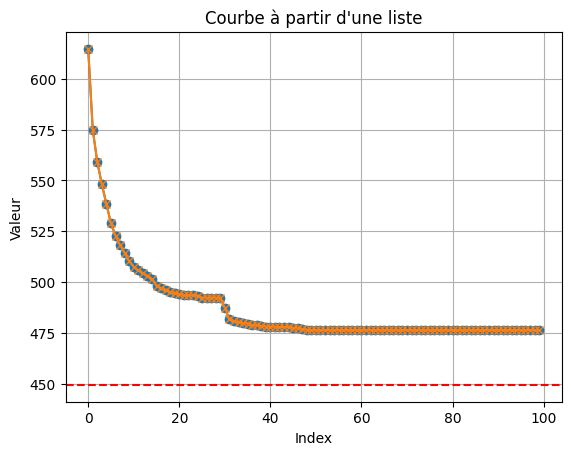

scenario s2
mct de l'ag : 484.2019230769231
evaluation of initial solution : 707.4038461538462
Iteration 84: meilleur coût = 554.1442307692307, patience : 50/50
temps ecoulé : 419.6844894886017
gap inbetween 14.444863673372108 %


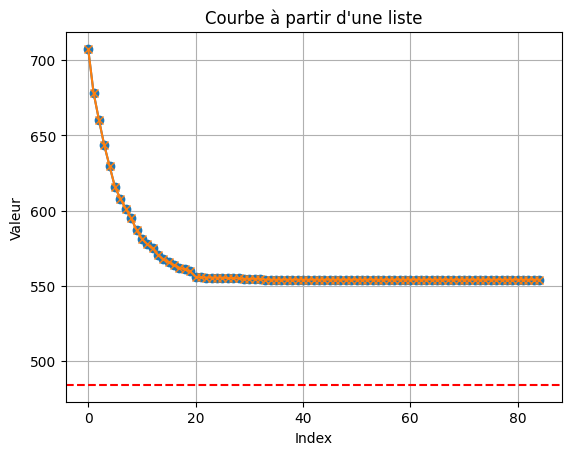

scenario s3
mct de l'ag : 407.6145833333333
evaluation of initial solution : 621.34375
Iteration 73: meilleur coût = 507.9166666666667, patience : 50/50
temps ecoulé : 321.86105489730835
gap inbetween 24.60708900871433 %


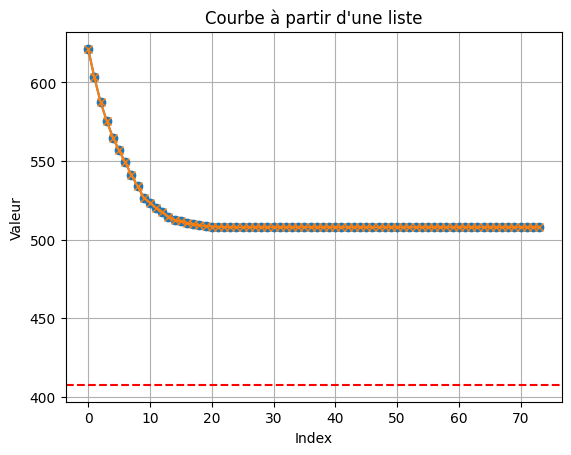

scenario s4
mct de l'ag : 449.5238095238095
evaluation of initial solution : 634.1904761904761
Iteration 79: meilleur coût = 494.2190476190476, patience : 50/50
temps ecoulé : 388.01333928108215
gap inbetween 9.942796610169491 %


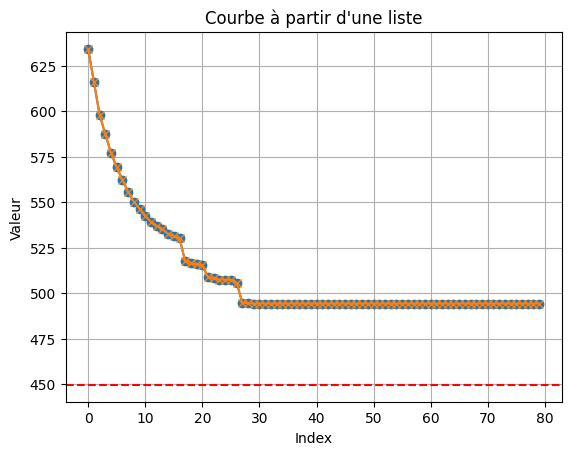

scenario s5
mct de l'ag : 428.92857142857144
evaluation of initial solution : 603.3163265306123
Iteration 72: meilleur coût = 518.3979591836735, patience : 50/50
temps ecoulé : 313.974582195282
gap inbetween 20.85880813607708 %


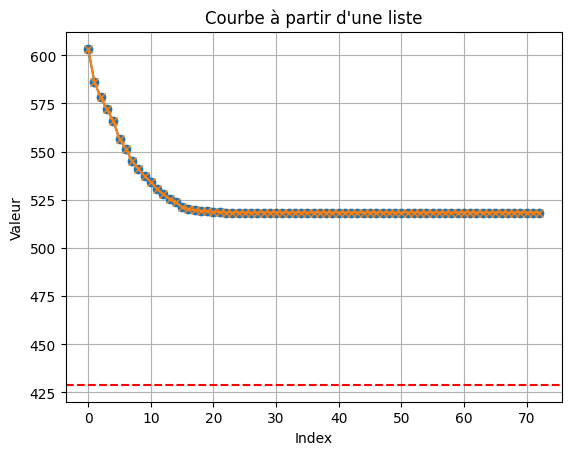

scenario s6
mct de l'ag : 393.0
evaluation of initial solution : 627.6122448979592
Iteration 118: meilleur coût = 463.55102040816325, patience : 50/50
temps ecoulé : 497.44584560394287
gap inbetween 17.951913589863423 %


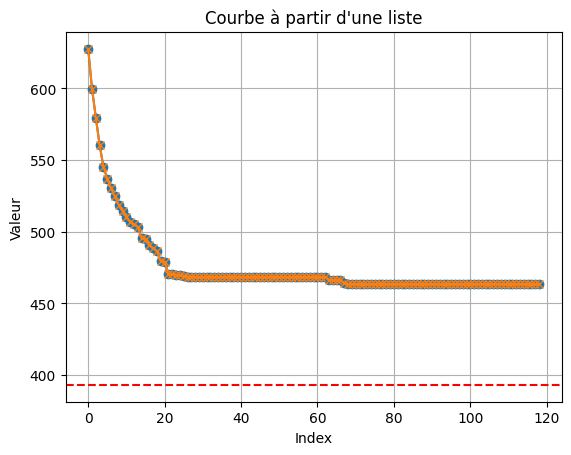

scenario s7
mct de l'ag : 441.03061224489795
evaluation of initial solution : 623.6020408163265
Iteration 85: meilleur coût = 492.8673469387755, patience : 50/50
temps ecoulé : 368.2448220252991
gap inbetween 11.753545730084909 %


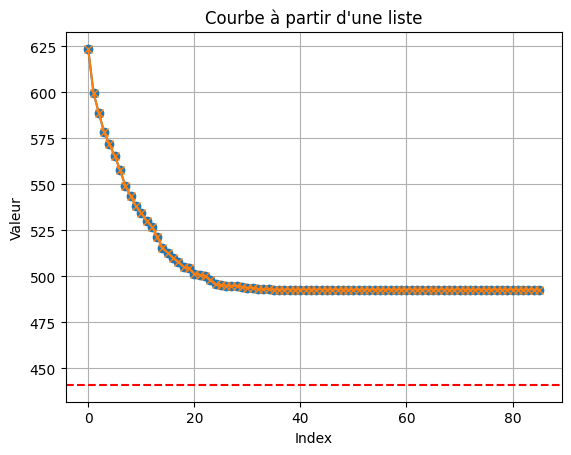

scenario s8
mct de l'ag : 432.44554455445547
evaluation of initial solution : 682.7920792079208
Iteration 96: meilleur coût = 502.0693069306931, patience : 50/500
temps ecoulé : 1419.7376163005829
gap inbetween 16.100006868603607 %


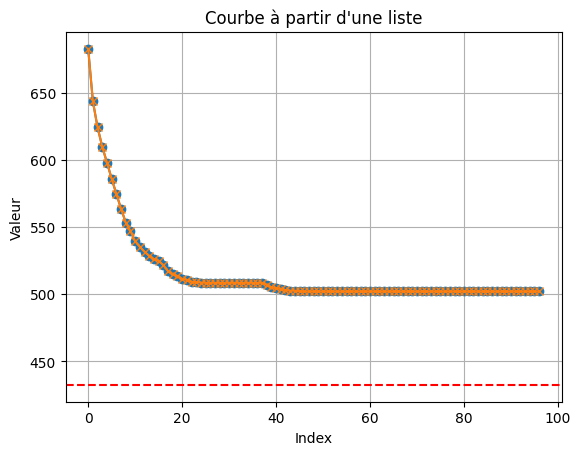

scenario s9
mct de l'ag : 424.6354166666667
evaluation of initial solution : 633.53125
Iteration 75: meilleur coût = 485.0520833333333, patience : 50/50
temps ecoulé : 310.81861424446106
gap inbetween 14.227891573653858 %


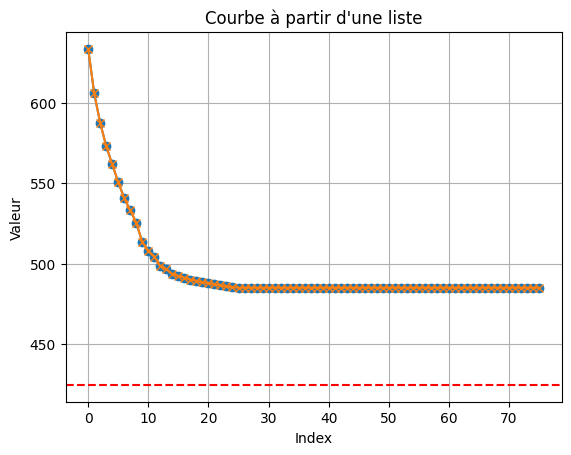

scenario s10
mct de l'ag : 420.70103092783506
evaluation of initial solution : 598.0721649484536
Iteration 79: meilleur coût = 467.1340206185567, patience : 50/50
temps ecoulé : 343.7600610256195
gap inbetween 11.03705155851793 %


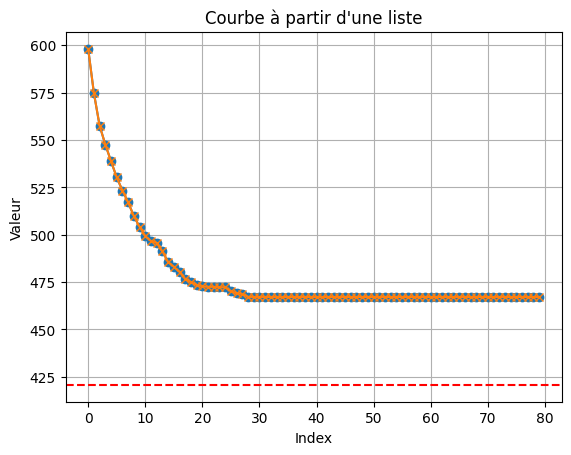

scenario s11
mct de l'ag : 409.2959183673469
evaluation of initial solution : 620.6122448979592
Iteration 89: meilleur coût = 471.234693877551, patience : 50/500
temps ecoulé : 402.0369131565094
gap inbetween 15.133005908603629 %


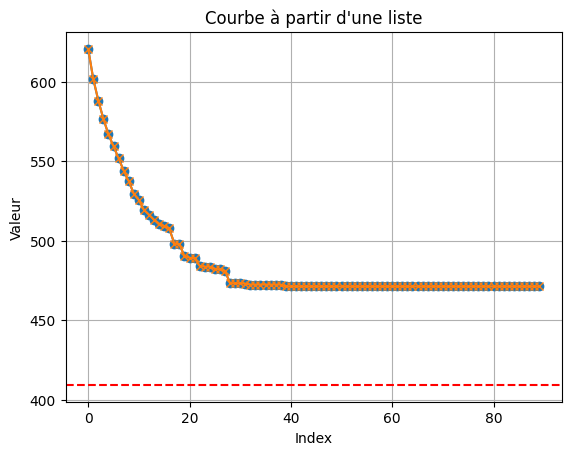

scenario s12
mct de l'ag : 449.4660194174757
evaluation of initial solution : 628.2135922330098
Iteration 76: meilleur coût = 510.59223300970876, patience : 50/50
temps ecoulé : 382.70844864845276
gap inbetween 13.599740792742207 %


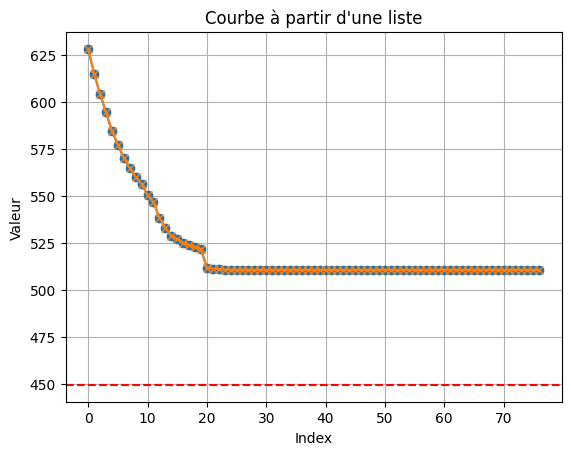

scenario s13
mct de l'ag : 435.33
evaluation of initial solution : 577.72
Iteration 99: meilleur coût = 478.1, patience : 50/50
temps ecoulé : 483.90297269821167
gap inbetween 9.824730664093915 %


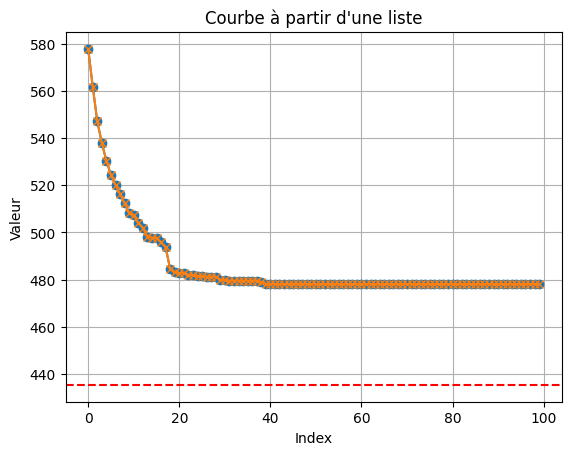

scenario s14
mct de l'ag : 437.74257425742576
evaluation of initial solution : 588.6237623762377
Iteration 73: meilleur coût = 501.26732673267327, patience : 50/50
temps ecoulé : 355.6922948360443
gap inbetween 14.511897222473534 %


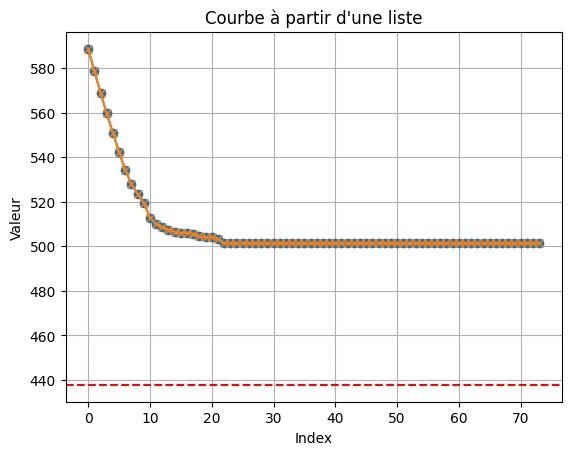

scenario s15
mct de l'ag : 419.3883495145631
evaluation of initial solution : 628.3786407766991
Iteration 89: meilleur coût = 487.2135922330097, patience : 50/50
temps ecoulé : 440.9028151035309
gap inbetween 16.172419380975526 %


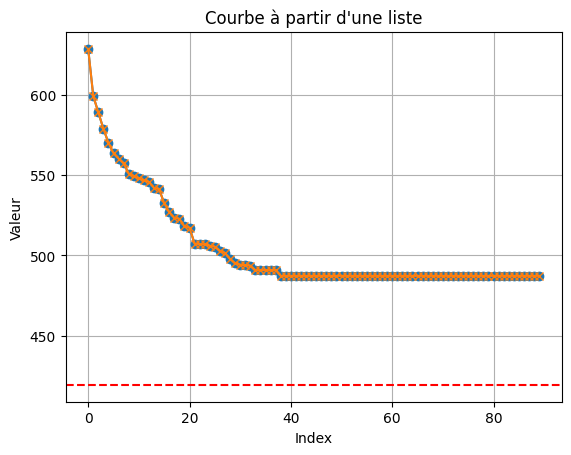

scenario s16
mct de l'ag : 442.6601941747573
evaluation of initial solution : 659.8349514563107
Iteration 132: meilleur coût = 480.50485436893206, patience : 50/50
temps ecoulé : 64424.892545223236
gap inbetween 8.549370531210249 %


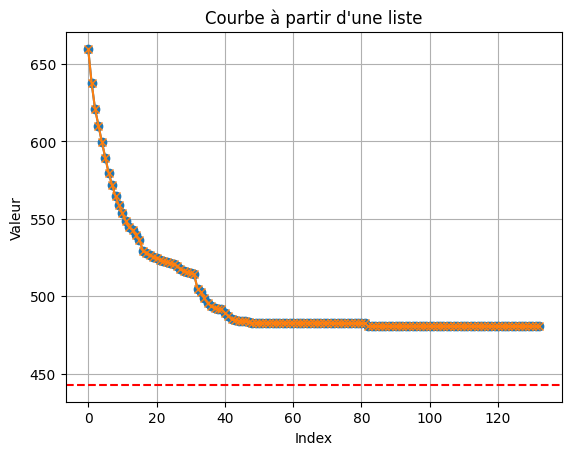

scenario s17
mct de l'ag : 396.0210526315789
evaluation of initial solution : 581.1157894736842
Iteration 135: meilleur coût = 428.14736842105265, patience : 50/50
temps ecoulé : 535.5835545063019
gap inbetween 8.112274732869075 %


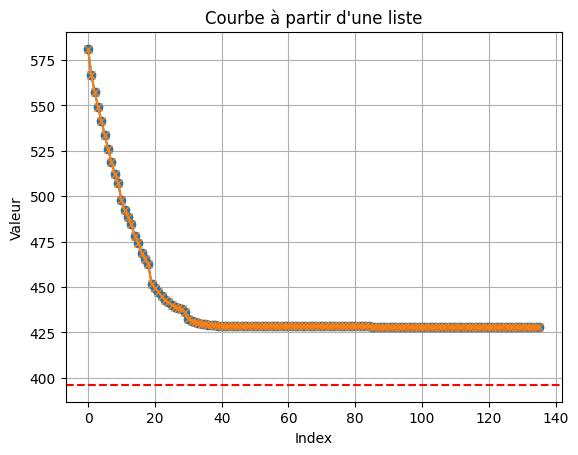

scenario s18
mct de l'ag : 459.28155339805824
evaluation of initial solution : 643.0679611650486
Iteration 104: meilleur coût = 548.2135922330098, patience : 50/50
temps ecoulé : 555.1685736179352
gap inbetween 19.363294296706567 %


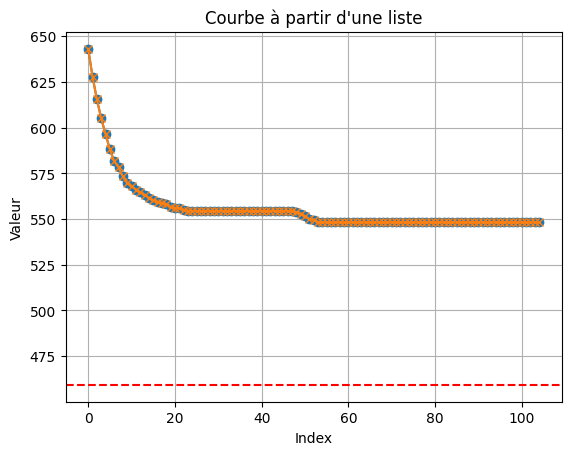

scenario s19
mct de l'ag : 443.64356435643566
evaluation of initial solution : 566.6930693069307
Iteration 70: meilleur coût = 479.26732673267327, patience : 50/50
temps ecoulé : 542.127843618393
gap inbetween 8.029816104267091 %


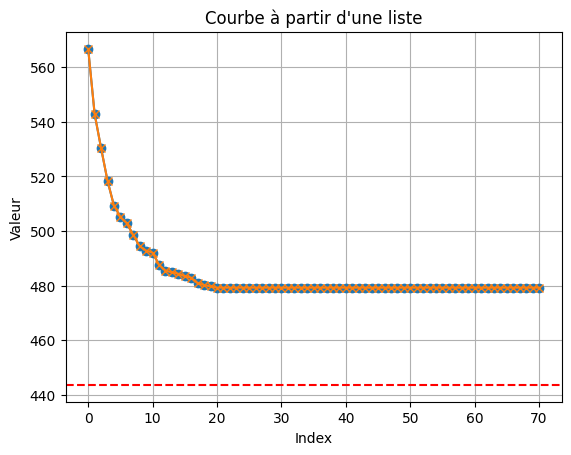

scenario s20
mct de l'ag : 434.52
evaluation of initial solution : 610.03
Iteration 95: meilleur coût = 505.97, patience : 50/50
temps ecoulé : 576.9482021331787
gap inbetween 16.443431832827038 %


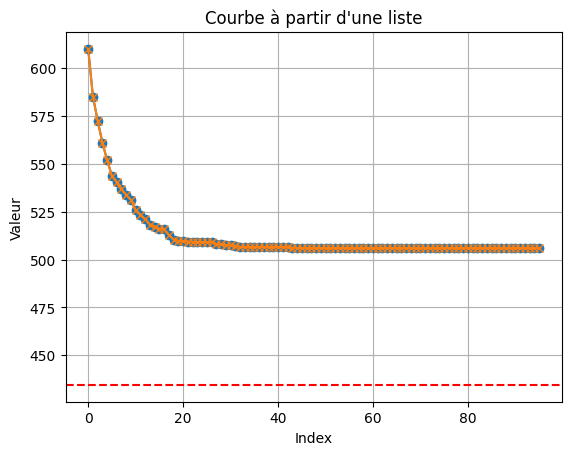

scenario s21
mct de l'ag : 419.734693877551
evaluation of initial solution : 625.469387755102
Iteration 67: meilleur coût = 515.2244897959183, patience : 50/50
temps ecoulé : 339.0857174396515
gap inbetween 22.75003646618368 %


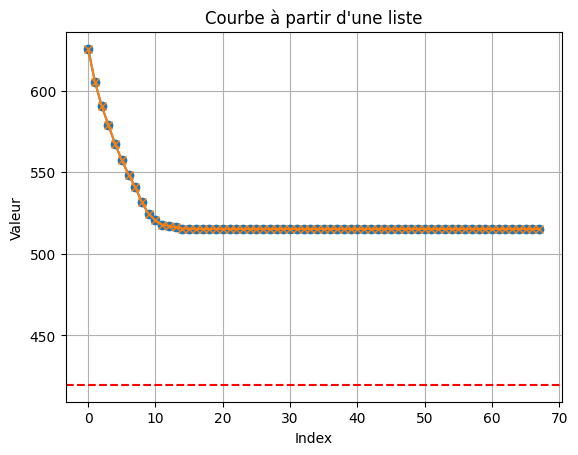

scenario s22
mct de l'ag : 427.7920792079208
evaluation of initial solution : 579.1089108910891
Iteration 122: meilleur coût = 468.55445544554453, patience : 50/50
temps ecoulé : 634.3460414409637
gap inbetween 9.528548614807784 %


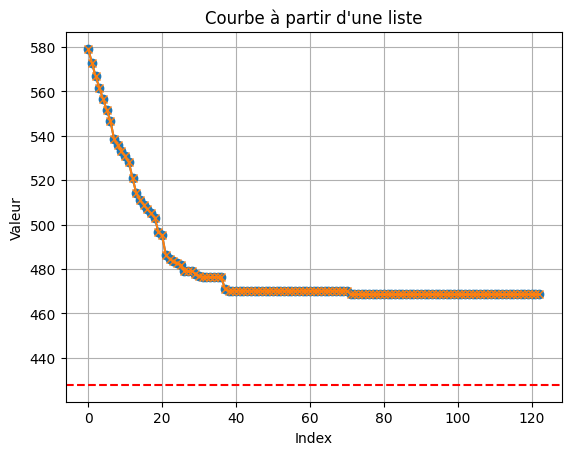

scenario s23
mct de l'ag : 425.3541666666667
evaluation of initial solution : 605.4791666666666
Iteration 84: meilleur coût = 471.8645833333333, patience : 50/50
temps ecoulé : 407.688777923584
gap inbetween 10.934515354851339 %


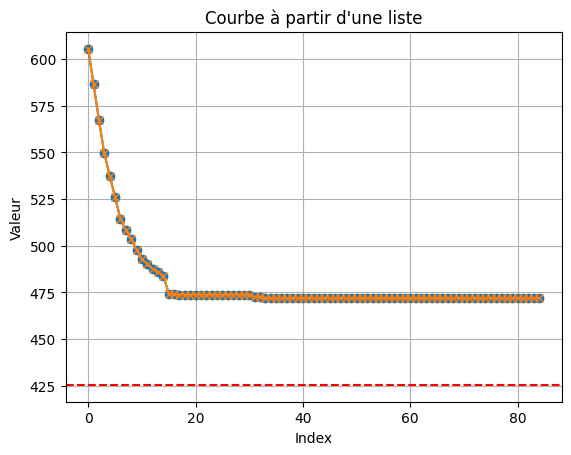

scenario s24
mct de l'ag : 437.3673469387755
evaluation of initial solution : 622.2142857142857
Iteration 72: meilleur coût = 500.1734693877551, patience : 50/50
temps ecoulé : 512.590494632721
gap inbetween 14.36003919555785 %


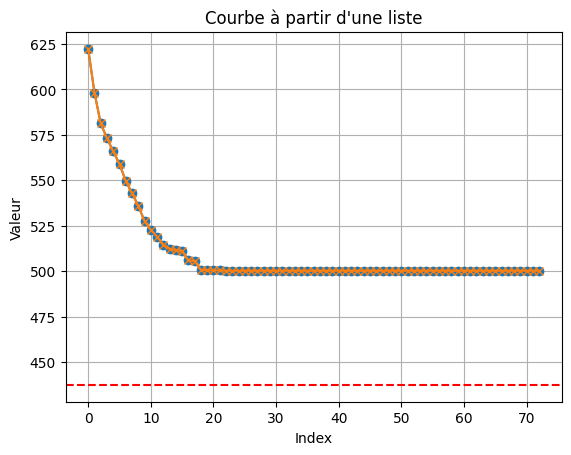

scenario s25
mct de l'ag : 427.03
evaluation of initial solution : 661.23
Iteration 85: meilleur coût = 493.06, patience : 50/50
temps ecoulé : 450.56705594062805
gap inbetween 15.462613867878142 %


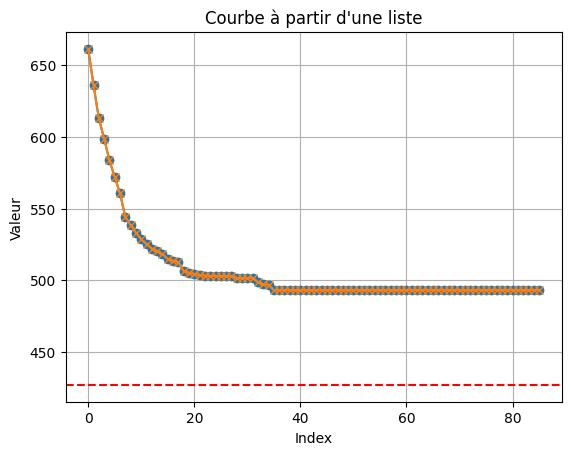

scenario s26
mct de l'ag : 420.4257425742574
evaluation of initial solution : 634.7029702970297
Iteration 85: meilleur coût = 485.1485148514852, patience : 50/50
temps ecoulé : 448.54878187179565
gap inbetween 15.394578809787353 %


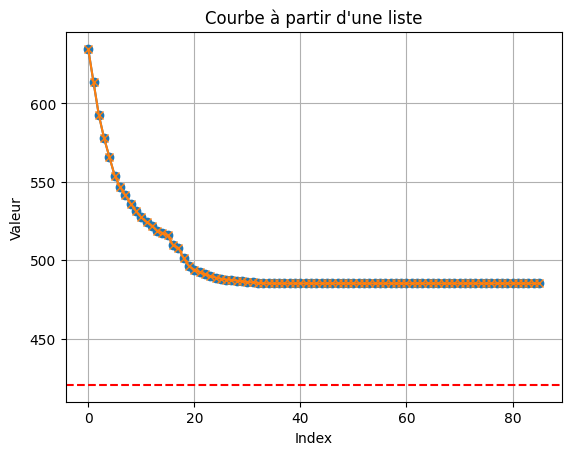

scenario s27
mct de l'ag : 412.8421052631579
evaluation of initial solution : 602.1894736842105
Iteration 87: meilleur coût = 455.4736842105263, patience : 50/50
temps ecoulé : 398.06889295578003
gap inbetween 10.326364099948995 %


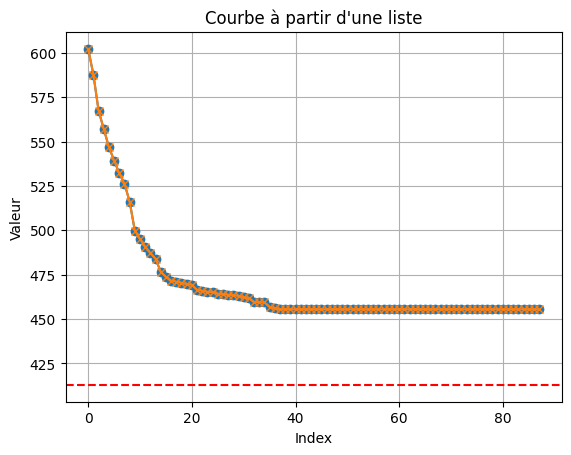

scenario s28
mct de l'ag : 418.3775510204082
evaluation of initial solution : 634.3265306122449
Iteration 84: meilleur coût = 474.1530612244898, patience : 50/50
temps ecoulé : 418.8847589492798
gap inbetween 13.331382161410696 %


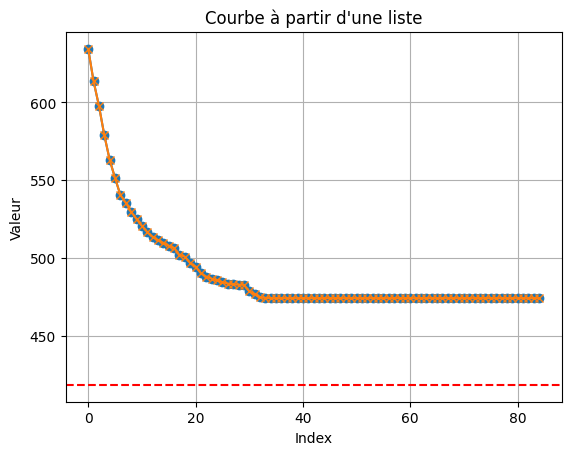

en moyenne on a gap 13.884198845628331 %


In [2]:
verbose = 1
ds = "K0"
scenarios_path_prefixe = f"scenarios/{ds}/"
solutions_path_prefixe = f"solution/{ds}_best/"

if ds.startswith("K"):
    fms = "3C7R5F"
    nombre_de_cellules = 3
elif ds.startswith("G"):
    fms = "5C14R5F"
    nombre_de_cellules = 5
with open(f'fms/{fms}.json', 'r') as json_file: #5C14R5F #3C7R5F
    dic = json.load(json_file)
system = sys.systeme(dic)

gaps = []

for scenario_path, solution_path in zip(sorted(os.listdir(scenarios_path_prefixe), key= lambda k : int(k[1:].split(".csv")[0])), sorted(os.listdir(solutions_path_prefixe), key= lambda k : int(k.split(".csv")[0].split("_s")[-1]))):
    scenario = pd.DataFrame(np.nan_to_num(pd.read_csv(scenarios_path_prefixe+scenario_path,header=None, index_col=None, sep=";"), nan=0)).astype(int).iloc[:,:-1]
    print(f"scenario {scenario_path.split("/")[-1].split(".")[0]}")
    ag_solution = pd.read_csv(solutions_path_prefixe+solution_path, sep=";", index_col=None, header=None).iloc[:,1:-1]
    ag_mct = simulation(system=system, scenario=scenario, allocators=[Allocation.StaticAllocator(system, ag_solution) for _ in range(nombre_de_cellules)]).mean_completion_time()
    print(f"mct de l'ag : {ag_mct}")
    start_time = time.time()
    recherche = recherche_taboue.TabuSearch(system, scenario, recherche_taboue.mean_completion_time, [recherche_taboue.voisinage_insert, recherche_taboue.voisinage_swap], 200, 50)
    best_solution, best_cost = recherche.run()
    print(f"\ntemps ecoulé : {time.time()-start_time}")
    gap = (best_cost-ag_mct)*100/ag_mct
    print(f"gap inbetween {gap} %")

    recherche.convergeance_graphic(ag_mct)
    gaps.append(gap)

print(f"en moyenne on a gap {sum(gaps)/len(gaps)} %")

  
# 547.1960784313726


In [5]:
# patience 1000, 
# taille liste taboue 200,
# moyenne gap  13.41349353060462 %
np.mean(gaps), np.min(gaps), np.max(gaps)

(13.88419884562833, 6.005540891341814, 24.60708900871433)